# Instructor solution · Lab 11 · Build a global minimum certificate

**Preparation:** [Lecture 11](../notebooks/11_global_optimization.ipynb).

**Time:** 2 hours plus 30–60 minutes homework. Complete the essential steps of a supplied branch-and-bound loop, compare two enclosure methods, and audit ties, boundary minima, and budget limits.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'solutions'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval, exact_fraction
from vc.enclosures import RangePiece, combined_enclosure
from vc.optimization import PrunedPiece, MinimumResult

def objective(X):
    return X.square().square() - 2*X.square()

def derivative(X):
    return 4*X*X*X - 4*X

def improved(X):
    return combined_enclosure(objective, derivative, X)

def plot_candidates(result):
    xs = np.linspace(-2, 2, 401)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(xs, xs**4-2*xs**2, color="black")
    for piece in result.candidates:
        part = piece.domain
        ax.axvspan(float(part.lo), float(part.hi), color="tab:green", alpha=0.2)
    ax.set(xlabel="x", ylabel="f(x)", title="Candidate minimizer intervals")
    return fig

## Task A · Complete the search loop (60 minutes)

Fill the three missing blocks: strict pruning, global lower bound and gap stopping, and child insertion with a feasible incumbent update. Preserve all records and the supplied budget outcomes. Each child midpoint is feasible; use the upper endpoint of its value enclosure. Use plain loops and named values.

In [3]:
def student_minimize(evaluate, domain, tolerance="1/1000", max_splits=128):
    tolerance = exact_fraction(tolerance)
    if tolerance <= 0:
        raise ValueError("tolerance must be positive")
    if not isinstance(max_splits, int) or max_splits < 0:
        raise ValueError("max_splits must be a nonnegative integer")
    witness = domain.midpoint()
    witness_value = evaluate(Interval(witness))
    # Endpoints are feasible points too; do not assume a minimum is stationary.
    for point in [domain.lo, domain.hi]:
        value = evaluate(Interval(point))
        if value.hi < witness_value.hi:
            witness, witness_value = point, value
    candidates = [RangePiece(domain, evaluate(domain))]
    pruned = []
    splits = 0
    while True:
        upper = witness_value.hi
        retained = []
        for piece in candidates:
            if piece.enclosure.lo > upper:
                pruned.append(PrunedPiece(piece, upper))
            else:
                retained.append(piece)
        candidates = retained
        if not candidates:
            raise ValueError("Inconsistent evaluator: every feasible candidate was pruned")
        best_index = 0
        for index in range(1, len(candidates)):
            current = candidates[index]
            best = candidates[best_index]
            if current.enclosure.lo < best.enclosure.lo:
                best_index = index
            elif current.enclosure.lo == best.enclosure.lo:
                if current.domain.width() > best.domain.width():
                    best_index = index
        best = candidates[best_index]
        lower = best.enclosure.lo
        if upper - lower <= tolerance:
            status = "gap_met"
            break
        if splits >= max_splits:
            status = "budget_exhausted"
            break
        if best.domain.width() == 0:
            status = "precision_limited"
            break
        left, right = best.domain.bisect()
        candidates.pop(best_index)
        for child in [left, right]:
            candidates.append(RangePiece(child, evaluate(child)))
            point = child.midpoint()
            value = evaluate(Interval(point))
            if value.hi < witness_value.hi:
                witness, witness_value = point, value
        splits += 1
    return MinimumResult(domain, Interval(lower, upper), candidates, witness,
                         witness_value, pruned, splits, status)

In [4]:
result = student_minimize(improved, Interval(-2, 2), tolerance="1/100", max_splits=512)
print(result.status, result.minimum, "splits:", result.splits)
assert result.status == "gap_met"
assert result.minimum.contains(-1)
assert result.minimum.width() <= Fraction(1, 100)
for minimizer in [-1, 1]:
    assert any(piece.domain.contains(minimizer) for piece in result.candidates)
for record in result.pruned:
    assert record.piece.enclosure.lo > record.incumbent_upper
assert result.domain.contains(result.witness)
assert result.minimum.hi == result.witness_value.hi

gap_met [-1055535/1048576, -1] splits: 29


**Worked explanation:** A feasible witness provides μ≤f(z)≤U. If a local lower bound exceeds U, no point of that box can minimize globally. Splitting retains a covering pair of children and pruning removes no minimizer, so induction preserves all minimizers. `minimum` encloses μ; the union of `candidates` encloses all minimizer locations. Neither claim says every retained point is a minimizer.

## Task B · Compare bounds and inspect coverage (35 minutes)

Compare natural and combined evaluators at the same value-gap target. Use the supplied plot helper. Verify that retained and pruned terminal domains together cover the original domain without gaps.

Natural splits: 175 combined splits: 29


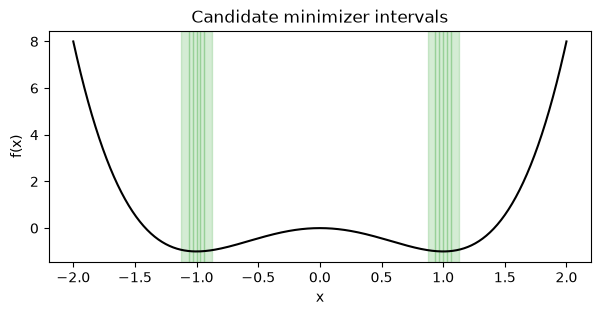

In [5]:
natural = student_minimize(objective, Interval(-2, 2), "1/100", 512)
print("Natural splits:", natural.splits, "combined splits:", result.splits)
assert natural.status == "gap_met"
assert natural.minimum.contains(-1)
fig = plot_candidates(result)
display(fig)
plt.close(fig)
terminal = [piece.domain for piece in result.candidates]
terminal.extend(record.piece.domain for record in result.pruned)
terminal.sort(key=lambda part: part.lo)
assert terminal[0].lo == -2 and terminal[-1].hi == 2
for left, right in zip(terminal, terminal[1:]):
    assert left.hi == right.lo

**Worked explanation:** Pruned boxes are certified to contain no minimizer, so the retained union need only cover the minimizer set. The full terminal record explains every removed part of the original domain. The better split count is specific to this run; interval overestimation and the cost of derivative evaluation depend on the function and domain.

## Task C · Ties, boundaries, and insufficient budgets (30 minutes plus homework)

Run these regression cases against your implementation. The tied-minimum example will expose unsafe pruning at equality. Record the conclusions of every stopping outcome.

In [6]:
ties = student_minimize(lambda X: (X.square()-1).square(), Interval(-2, 2))
for minimizer in [-1, 1]:
    assert any(piece.domain.contains(minimizer) for piece in ties.candidates)
assert ties.minimum.lo == ties.minimum.hi == 0

boundary = student_minimize(lambda X: X, Interval(0, 1))
assert boundary.witness == 0
assert boundary.minimum.lo == boundary.minimum.hi == 0
constant = student_minimize(lambda X: Interval(3), Interval(-10, 10))
assert constant.minimum.width() == 0
assert constant.candidates[0].domain.width() == 20
limited = student_minimize(improved, Interval(-2, 2), "1/1000000", 2)
assert limited.status == "budget_exhausted"
assert limited.minimum.contains(-1)
for name, case in [("ties", ties), ("boundary", boundary), ("constant", constant), ("budget", limited)]:
    print(name, case.status, case.minimum, "candidates:", len(case.candidates))

ties gap_met [0, 0] candidates: 2
boundary gap_met [0, 0] candidates: 1
constant gap_met [3, 3] candidates: 1
budget budget_exhausted [-8, -1] candidates: 3


**Worked explanation:** Equality can occur in a box containing a tied minimizer, so ≥ could discard a true minimizer. Boundary points are feasible and may minimize a monotone objective. A constant function has the same value everywhere, so its exact value gives no localization. After budget exhaustion, the returned minimum interval and candidate union remain rigorous under the evaluator premises, but the requested gap is not claimed.